In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import os

In [31]:
# If running from inside the 'notebook' folder, change working directory to the parent folder
if os.path.basename(os.getcwd()) == 'notebook':
    os.chdir('..')

In [32]:
# Create necessary directories
os.makedirs('images', exist_ok=True)
os.makedirs('model', exist_ok=True)

In [33]:
print("Loading datasets...")
hotel_df = pd.read_csv('data/hotel_booking.csv')
energy_df = pd.read_excel('data/ENB2012_data.xlsx')

Loading datasets...


In [34]:
print("1. PREPROCESSING & EDA: HOTEL BOOKING DATASET")
# Handle missing values
hotel_df['children'] = hotel_df['children'].fillna(0)
hotel_df['country'] = hotel_df['country'].fillna('Unknown')
hotel_df.drop(['agent', 'company'], axis=1, inplace=True, errors='ignore')

1. PREPROCESSING & EDA: HOTEL BOOKING DATASET


In [35]:
# Feature selection & engineering
# We need Month, Number of guests, Length of stay
hotel_df['Number_of_guests'] = hotel_df['adults'] + hotel_df['children'] + hotel_df['babies']
hotel_df['Length_of_stay'] = hotel_df['stays_in_weekend_nights'] + hotel_df['stays_in_week_nights']
hotel_df['Month'] = hotel_df['arrival_date_month']

In [36]:
# Convert Month to numeric (e.g. Label Encoding)
month_map = {'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6, 
             'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12}
hotel_df['Month_num'] = hotel_df['Month'].map(month_map)

In [37]:
# We want to predict "Occupancy or booking demand". 
# Let's use an aggregated occupancy factor based on guests and stay duration, normalized.
hotel_df['Occupancy'] = hotel_df['Number_of_guests'] * hotel_df['Length_of_stay']
max_occ = hotel_df['Occupancy'].max()
hotel_df['Occupancy_pct'] = hotel_df['Occupancy'] / max_occ

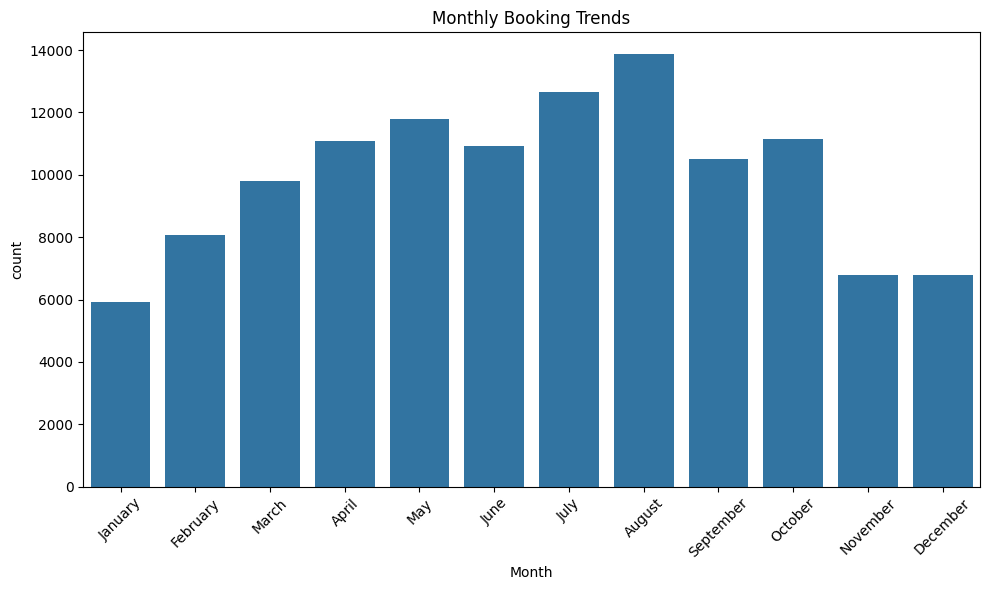

In [38]:
# EDA: Hotel
plt.figure(figsize=(10,6))
sns.countplot(data=hotel_df, x='Month', order=month_map.keys())
plt.title('Monthly Booking Trends')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/monthly_booking_trends.png')

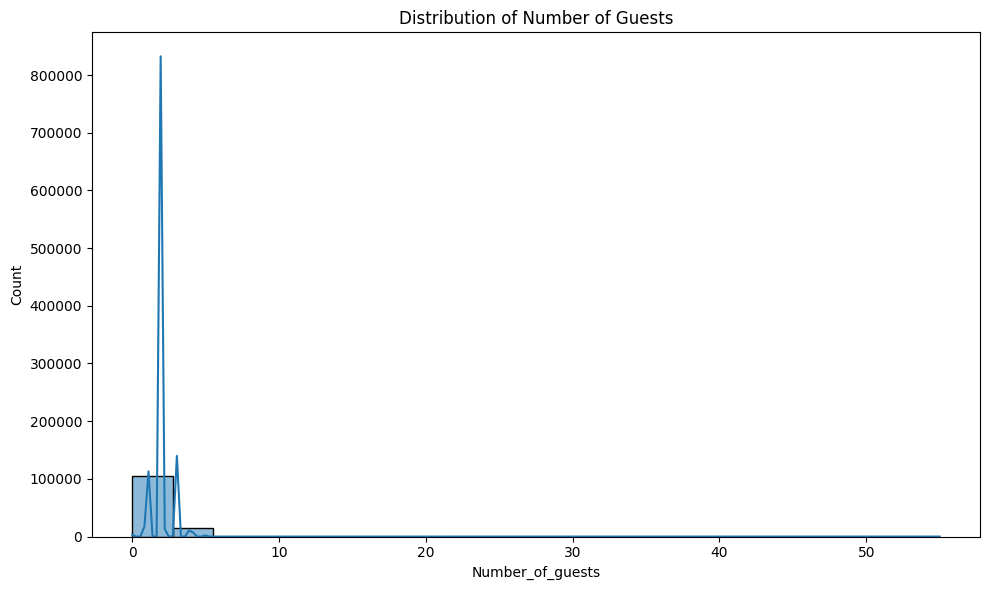

In [39]:
plt.figure(figsize=(10,6))
sns.histplot(hotel_df['Number_of_guests'], bins=20, kde=True)
plt.title('Distribution of Number of Guests')
plt.tight_layout()
plt.savefig('images/guest_distribution.png')

In [40]:
print("Training Model 1 (Demand Prediction)...")
features_hotel = ['Month_num', 'Number_of_guests', 'Length_of_stay']
X_hotel = hotel_df[features_hotel]
y_hotel = hotel_df['Occupancy_pct']

Training Model 1 (Demand Prediction)...


In [41]:
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_hotel, y_hotel, test_size=0.2, random_state=42)
model_hotel = RandomForestRegressor(n_estimators=10, random_state=42) # reduced trees for speed
model_hotel.fit(X_train_h, y_train_h)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [42]:
pred_h = model_hotel.predict(X_test_h)
print(f"Hotel Model R2: {r2_score(y_test_h, pred_h):.4f}")
joblib.dump(model_hotel, 'model/demand_model.pkl')

Hotel Model R2: 0.9872


['model/demand_model.pkl']

In [43]:
print("2. PREPROCESSING & EDA: ENERGY EFFICIENCY DATASET (ENB2012)")
# Rename columns to meaningful names
# X1=Relative Compactness, X2=Surface Area, X3=Wall Area, X4=Roof Area,
# X5=Building Height, X6=Orientation, X7=Glazing Area, X8=Glazing Area Distribution
# Y1=Heating Load, Y2=Cooling Load
energy_df.rename(columns={
    'X1': 'Relative_Compactness',
    'X2': 'Surface_Area',
    'X3': 'Wall_Area',
    'X4': 'Roof_Area',
    'X5': 'Building_Height',
    'X6': 'Orientation',
    'X7': 'Glazing_Area',
    'X8': 'Glazing_Area_Distribution',
    'Y1': 'Heating_Load',
    'Y2': 'Cooling_Load'
}, inplace=True)

print(f"ENB2012 dataset loaded: {energy_df.shape[0]} samples, {energy_df.shape[1]} features")


2. PREPROCESSING & EDA: ENERGY EFFICIENCY DATASET (ENB2012)
ENB2012 dataset loaded: 768 samples, 10 features


In [44]:
# Synthetic load generation removed

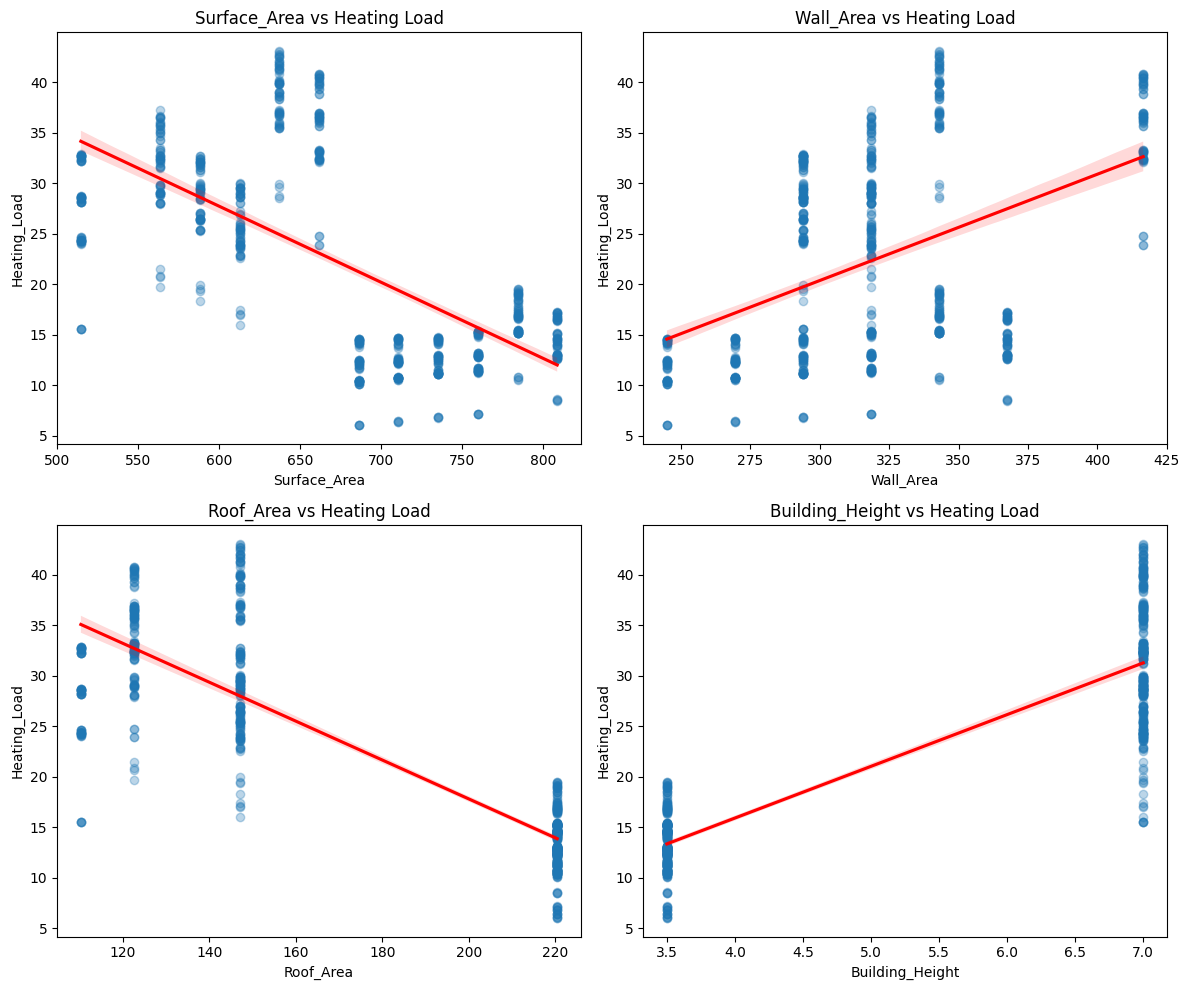

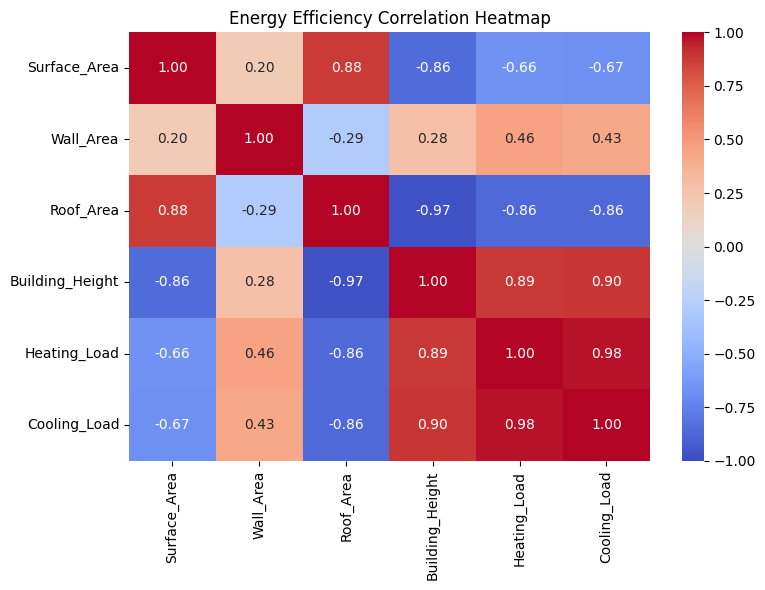

In [45]:
# EDA: Energy
# 1. Relationship between heating load and input features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ['Surface_Area', 'Wall_Area', 'Roof_Area', 'Building_Height']
for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    sns.regplot(data=energy_df, x=feature, y='Heating_Load', scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=axes[row, col])
    axes[row, col].set_title(f'{feature} vs Heating Load')
plt.tight_layout()
plt.savefig('images/heating_load_features.png')
plt.show()

# 2. Cooling load trends and correlations (Correlation Heatmap)
plt.figure(figsize=(8, 6))
correlation_cols = ['Surface_Area', 'Wall_Area', 'Roof_Area', 'Building_Height', 'Heating_Load', 'Cooling_Load']
corr = energy_df[correlation_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Energy Efficiency Correlation Heatmap')
plt.tight_layout()
plt.savefig('images/energy_correlation.png')
plt.show()


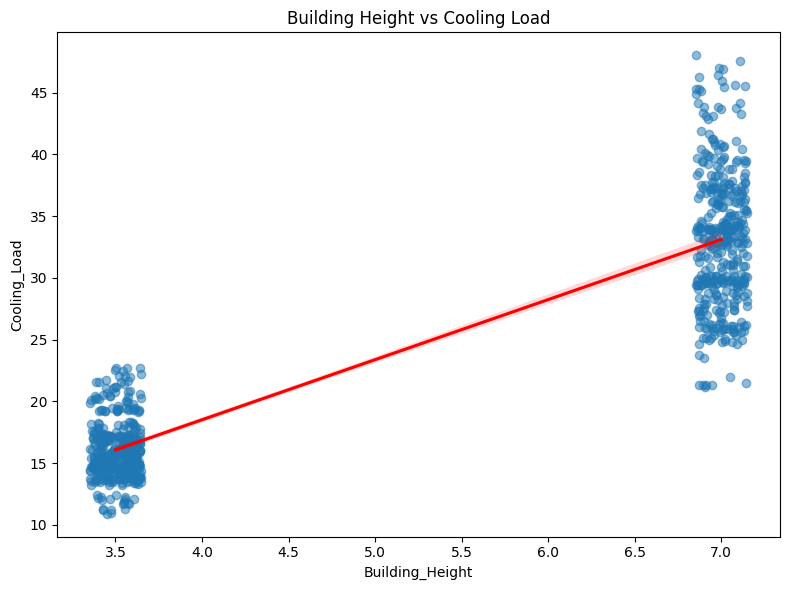

In [46]:
plt.figure(figsize=(8,6))
sns.regplot(data=energy_df, x='Building_Height', y='Cooling_Load', x_jitter=0.15, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Building Height vs Cooling Load')
plt.tight_layout()


In [47]:
print("Training Model 2 (Energy Prediction)...")
features_energy = ['Surface_Area', 'Wall_Area', 'Roof_Area', 'Building_Height']
X_energy = energy_df[features_energy]
y_energy = energy_df[['Heating_Load', 'Cooling_Load']]

Training Model 2 (Energy Prediction)...


In [48]:
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_energy, y_energy, test_size=0.2, random_state=42)
model_energy = LinearRegression()
model_energy.fit(X_train_e, y_train_e)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [49]:
pred_e = model_energy.predict(X_test_e)
print(f"Energy Model R2: {r2_score(y_test_e, pred_e):.4f}")
joblib.dump(model_energy, 'model/energy_model.pkl')

Energy Model R2: 0.8510


['model/energy_model.pkl']

In [50]:
print("All models trained and saved successfully.")

All models trained and saved successfully.
